In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Todo funciona perfectamente")

Todo funciona perfectamente


In [2]:
import wfdb

record = wfdb.rdrecord('mitdb/100', sampto=3000)
annotation = wfdb.rdann('mitdb/100', 'atr', sampto=3000)
print("Datos ECG descargados correctamente")
print(f"Frecuencia de muestreo: {record.fs} Hz")
print(f"Número de muestras: {len(record.p_signal)}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/josem/mitdb/100.hea'

In [3]:
wfdb.dl_database('mitdb', dl_dir='mitdb', records=['100'])
print("Base de datos descargada")

Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: mitdb
Finished downloading files
Base de datos descargada


In [4]:
record = wfdb.rdrecord('mitdb/100', sampto=3000)
annotation = wfdb.rdann('mitdb/100', 'atr', sampto=3000)
print("Datos ECG cargados correctamente")
print(f"Frecuencia de muestreo: {record.fs} Hz")
print(f"Número de muestras: {len(record.p_signal)}")

Datos ECG cargados correctamente
Frecuencia de muestreo: 360 Hz
Número de muestras: 3000


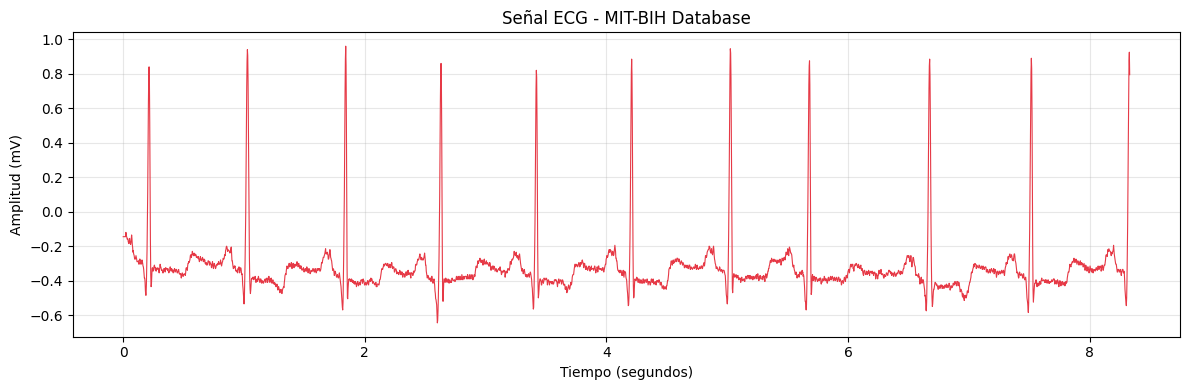

In [5]:
import matplotlib.pyplot as plt
import numpy as np

señal = record.p_signal[:, 0]
fs = record.fs
tiempo = np.arange(len(señal)) / fs

plt.figure(figsize=(12, 4))
plt.plot(tiempo, señal, color='#e63946', linewidth=0.8)
plt.title('Señal ECG - MIT-BIH Database')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud (mV)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
df = pd.DataFrame({
    'tiempo_s': annotation.sample[1:] / fs,
    'intervalo_rr': np.diff(annotation.sample) / fs,
    'frecuencia_cardiaca': 60 / (np.diff(annotation.sample) / fs)
})

print(df.describe())

        tiempo_s  intervalo_rr  frecuencia_cardiaca
count  11.000000     11.000000            11.000000
mean    4.232323      0.752525           101.131027
std     2.676038      0.210318            88.178659
min     0.213889      0.163889            60.335196
25%     2.233333      0.788889            73.594762
50%     4.208333      0.811111            73.972603
75%     6.175000      0.815278            76.056338
max     8.327778      0.994444           366.101695


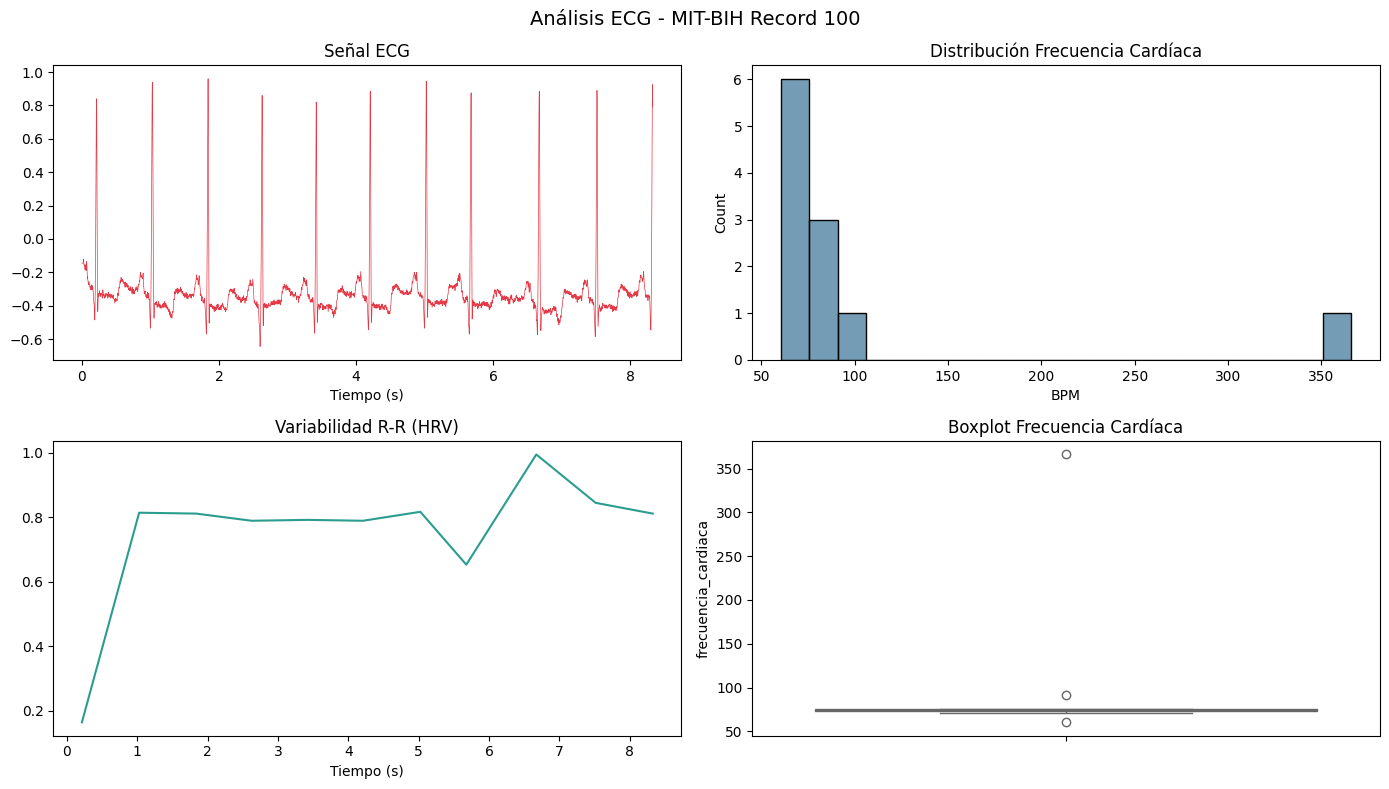

In [7]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Análisis ECG - MIT-BIH Record 100', fontsize=14)

axes[0,0].plot(tiempo, señal, color='#e63946', linewidth=0.5)
axes[0,0].set_title('Señal ECG')
axes[0,0].set_xlabel('Tiempo (s)')

sns.histplot(df['frecuencia_cardiaca'], ax=axes[0,1], color='#457b9d', bins=20)
axes[0,1].set_title('Distribución Frecuencia Cardíaca')
axes[0,1].set_xlabel('BPM')

axes[1,0].plot(df['tiempo_s'], df['intervalo_rr'], color='#2a9d8f')
axes[1,0].set_title('Variabilidad R-R (HRV)')
axes[1,0].set_xlabel('Tiempo (s)')

sns.boxplot(y=df['frecuencia_cardiaca'], ax=axes[1,1], color='#e9c46a')
axes[1,1].set_title('Boxplot Frecuencia Cardíaca')

plt.tight_layout()
plt.savefig('ecg_dashboard.png', dpi=150)
plt.show()